# RABTECH Academy – Task 3
## Feature Engineering & Preprocessing Pipeline

### Objective

Build a robust, leak-free machine learning preprocessing pipeline using
Scikit-Learn's ColumnTransformer and Pipeline.

The project includes:
- Numerical feature scaling
- Categorical feature encoding
- Train/test splitting before preprocessing
- Tree-based feature importance analysis

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (32561, 15)


In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (32561, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Missing values:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income         

In [5]:
# Clean the target column
df["income"] = df["income"].str.strip()

# Convert target to binary values
df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Check the target
print(df["income"].value_counts())

income
0    24720
1     7841
Name: count, dtype: int64


In [6]:
# Separate features and target
X = df.drop(columns=["income"])
y = df["income"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32561, 14)
Target shape: (32561,)


In [7]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [8]:
# Split the data BEFORE applying any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (26048, 14)
Testing data: (6513, 14)

Training target distribution:
income
0    19775
1     6273
Name: count, dtype: int64

Testing target distribution:
income
0    4945
1    1568
Name: count, dtype: int64


In [9]:
# Numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print("Preprocessing pipelines created successfully!")

Preprocessing pipelines created successfully!


In [10]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("ColumnTransformer created successfully!")

ColumnTransformer created successfully!


In [11]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [12]:
# Create the complete machine learning pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Complete ML pipeline created successfully!")

Complete ML pipeline created successfully!


In [13]:
# Train the complete pipeline
model_pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

print("Predictions completed successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed successfully!
First 20 predictions:
[0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0]


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation tools imported successfully!")

Evaluation tools imported successfully!


In [16]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation
-----------------
Accuracy : 0.8575
Precision: 0.7356
Recall   : 0.6371
F1 Score : 0.6828


In [17]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4945
           1       0.74      0.64      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.80      6513
weighted avg       0.85      0.86      0.85      6513

Confusion Matrix:
[[4586  359]
 [ 569  999]]


In [18]:
# Get feature names after preprocessing
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("\nFirst 20 feature names:")
print(feature_names[:20])

Number of transformed features: 105

First 20 feature names:
['num__age' 'num__fnlwgt' 'num__education_num' 'num__capital_gain'
 'num__capital_loss' 'num__hours_per_week' 'cat__workclass_Federal-gov'
 'cat__workclass_Local-gov' 'cat__workclass_Never-worked'
 'cat__workclass_Private' 'cat__workclass_Self-emp-inc'
 'cat__workclass_Self-emp-not-inc' 'cat__workclass_State-gov'
 'cat__workclass_Without-pay' 'cat__education_10th' 'cat__education_11th'
 'cat__education_12th' 'cat__education_1st-4th' 'cat__education_5th-6th'
 'cat__education_7th-8th']


In [19]:
# Get feature importance from Random Forest
importances = model_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 15 most important features:")
print(feature_importance_df.head(15))

Top 15 most important features:
                                   feature  importance
1                              num__fnlwgt    0.163055
0                                 num__age    0.151064
3                        num__capital_gain    0.093213
5                      num__hours_per_week    0.083402
32  cat__marital_status_Married-civ-spouse    0.063187
2                       num__education_num    0.062670
51               cat__relationship_Husband    0.050494
4                        num__capital_loss    0.031644
34       cat__marital_status_Never-married    0.025806
40         cat__occupation_Exec-managerial    0.017879
23                cat__education_Bachelors    0.014231
46          cat__occupation_Prof-specialty    0.011348
9                   cat__workclass_Private    0.011288
52         cat__relationship_Not-in-family    0.009529
54             cat__relationship_Own-child    0.009062


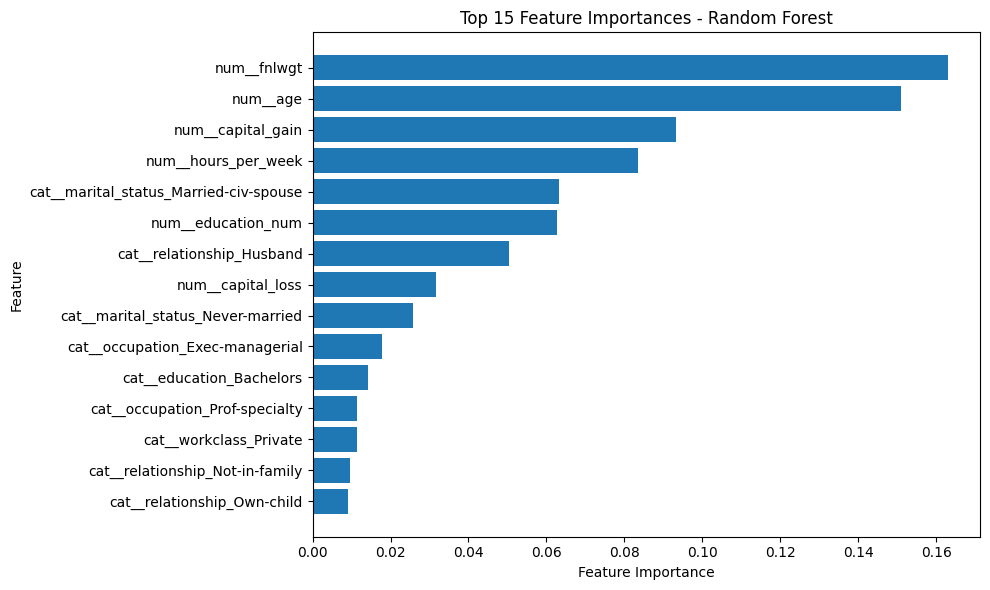

In [20]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [21]:
print("Final Model Evaluation")
print("======================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Final Model Evaluation
Accuracy : 0.8575
Precision: 0.7356
Recall   : 0.6371
F1 Score : 0.6828


## Conclusion

This project demonstrates a robust and leak-free feature engineering and preprocessing pipeline using Scikit-Learn.

The workflow:
- Loaded a complex tabular dataset.
- Split the data into training and testing sets before preprocessing.
- Used ColumnTransformer for separate numerical and categorical preprocessing.
- Applied StandardScaler to numerical features.
- Applied One-Hot Encoding to categorical features.
- Combined preprocessing and Random Forest classification into a reusable Pipeline.
- Evaluated the model using accuracy, precision, recall, and F1 score.
- Performed tree-based feature importance analysis.

The final model achieved an accuracy of 85.75% on the test set.

The feature importance analysis provides insight into which transformed features contributed most to the Random Forest predictions.